<h1 align="center"> Baseline Models - Embeddings </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
# Additional imports needed to load src.model and src.dataset
import sys
sys.path.append("..")

import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import torch
import pandas as pd
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from src.model import CLIPModel, RNAEncoder, ImageEncoder, ContrastiveLoss
from src.dataset import RNACustomDataset, ImgCustomDataset
from sklearn.model_selection import train_test_split
import torch.nn as nn 
import numpy as np
import albumentations as albu # For image augmentations
import cv2
from albumentations.pytorch import ToTensorV2
from src.optimise import set_seed, calc_mean_std, generate_model_name, capitalize_j, format_case_id
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import spearmanr
np.random.seed(2)

# Set random seed for weights
random_seed = 2
set_seed(random_seed)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
import sklearn.metrics as mx
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report

from imblearn.ensemble import BalancedRandomForestClassifier

Random seed set as 2


<i> Helper Functions: <i>

In [2]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

def modelPerformance(confMat):
    TN = confMat[0, 0]
    TP = confMat[1, 1]
    FP = confMat[0, 1]
    FN = confMat[1, 0]
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    spec = TN / (TN + FP)
    fpr = FP / (TN + FP)
    f1 = 2 * (prec * rec) / (prec + rec)
    acc = (TP + TN) / (TP + FP + TN + FN)
    return (acc, prec, rec, spec, fpr, f1)

def printPerformance(confMat):
    acc, prec, rec, spec, fpr, f1 = modelPerformance(confMat)
    print("Accuracy = " "%.4f" % acc)
    print("Precision = " "%.4f" % prec)
    print("Recall = " "%.4f" % rec)
    print("Specificity = " "%.4f" % spec)
    print("False positive rate = " "%.4f" % fpr)
    print("F1-score = " "%.4f" % f1)
    np.set_printoptions(precision=2)
    print("Confusion matrix (%):")
    print(confMat/np.sum(confMat)*100)

def proximityMatrix(mdl, X, normalize=True):      
    endNode = mdl.apply(X)
    nTrees = endNode.shape[1]
    n = X.shape[0]
    proxMat = np.zeros((n,n))
    for k in range(0, nTrees):
        a = endNode[:,k]
        proxMat += 1*np.equal.outer(a, a)
    if normalize:
        proxMat = proxMat / nTrees
    return proxMat

### Matching Samples for Analysis

In [3]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [4]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


### Pair Images and RNA Data

In [5]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id2)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id2)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rad)
print(f"Matching Images: ", flag2)

flag3 = (rna_paired_id_list == rad_paired_id_list)
print(f"Matching IDs: ", flag3)

Matching Diagnoses:  True
Matching Images:  True
Matching IDs:  True


In [9]:
# Create DataFrame for surgical matching
match_dict = {"image_name": image_filenames_rad, "ID": rad_paired_id_list, "SURGICAL": surgical_rad} 
match_df = pd.DataFrame(match_dict)
match_df

,image_name,ID,SURGICAL
0,12930_3.nii.gz,12930,B-S
1,13291_0010.nii.gz,13291,M-S
2,14023_3.nii.gz,14023,M-S
3,14056_3.nii.gz,14056,M-S
4,14654_3.nii.gz,14654,M-S
5,14024_2.nii.gz,14024,M-S
6,14984_0039.nii.gz,14984,M-S
7,16106_0022.nii.gz,16106,B-S
8,16134_0049.nii.gz,16134,M-S
9,16208_1.nii.gz,16208,B-S


### Get Unpaired Images and RNA Data 
(_validation_)

In [10]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)
# Filter columns
surg_placeholder = df_radiomics["SURGICAL"]
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED
df_radiomics.insert(0, "SURGICAL", surg_placeholder)
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].str.strip() 
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["B-NS", "B-NS -->THEATRE"], "B-S")
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["M-NS"], "M-S")
df_radiomics = df_radiomics.loc[df_radiomics["SURGICAL"] != "NS"]
df_radiomics["ID"] = df_radiomics["ID"].astype(str)

In [11]:
rad_paired_id_list_noj = list(map(lambda x: "26246" if x == "J630" else x, rad_paired_id_list))
df_unpaired_rad = df_radiomics[~df_radiomics["ID"].isin(rad_paired_id_list_noj)]
df_unpaired_rna = df_merged_copy[~df_merged_copy["CASE ID"].isin(rna_paired_id_list) & ~df_merged_copy["CASE ID2"].isin(rna_paired_id_list)]


In [12]:
# Check length of both unpaired sample dataframes
print("Number of rows in unpaired radiomics samples:", df_unpaired_rad.shape[0])
print("Number of rows in unpaired RNA samples:", df_unpaired_rna.shape[0])

Number of rows in unpaired radiomics samples: 547
Number of rows in unpaired RNA samples: 38


In [13]:
check1 = df_unpaired_rad["ID"].to_list()
check2 = rad_paired_id_list
set(check1) & set(check2)

set()

In [14]:
check1 = df_unpaired_rna["CASE ID"].to_list() + df_unpaired_rna["CASE ID2"].to_list()
check2 = rna_paired_id_list
set(check1) & set(check2)

set()

In [15]:
# Create DataFrame for surgical matching
match_rad_dict = {"CASE ID": df_unpaired_rad["ID"].astype("int64"), "SURGICAL": df_unpaired_rad["SURGICAL"]} 
match_rad_df = pd.DataFrame(match_rad_dict)
match_rad_df

,CASE ID,SURGICAL
0,11935,B-S
1,12041,B-S
2,12165,B-S
3,12287,M-S
4,12665,M-S
...,...,...
572,756,B-S
573,757,B-S
574,759,B-S
575,760,M-S


In [16]:
# Create DataFrame for surgical matching
match_rna_dict = {"CASE ID": df_unpaired_rna["CASE ID"], "CASE ID2": df_unpaired_rna["CASE ID2"], "SURGICAL": df_unpaired_rna["SURGICAL"]} 
match_rna_df = pd.DataFrame(match_rna_dict)
match_rna_df

,CASE ID,CASE ID2,SURGICAL
0,12930,NaN,B-S
1,13291,NaN,M-S
2,13750,NaN,M-S
3,14023,NaN,M-S
4,14056,NaN,M-S
5,14654,NaN,M-S
6,14024,NaN,M-S
7,14984,NaN,M-S
8,16106,NaN,B-S
9,16134,NaN,M-S


In [17]:
df_images_ids = df_images[["SURGICAL", "CASE ID", "CASE ID2"]]
df_images_ids = df_images_ids.drop_duplicates(keep="first")
df_images_ids

,SURGICAL,CASE ID,CASE ID2
0,M-S,12287,NaN
3,B-S,12930,NaN
9,M-S,13291,NaN
13,M-S,13750,NaN
18,M-S,14023,NaN
21,M-S,14056,NaN
23,M-S,14654,NaN
24,M-S,14024,NaN
26,M-S,14984,NaN
30,B-S,15346,NaN


In [18]:
df_images_merged = pd.merge(match_rad_df, df_images_ids, how='outer', on=['CASE ID'])
df_images_merged["SURGICAL_x"] = df_images_merged["SURGICAL_x"].fillna(df_images_merged["SURGICAL_y"])
df_images_merged = df_images_merged.drop("SURGICAL_y", axis="columns")
df_images_merged = df_images_merged.rename(columns={"SURGICAL_x": "SURGICAL"})
df_images_merged = df_images_merged[["CASE ID", "CASE ID2", "SURGICAL"]]
merged_id_list = match_rad_df["CASE ID"].tolist()
mask_merged = df_images_merged["CASE ID"].isin(merged_id_list)
df_images_merged = df_images_merged[mask_merged]
df_images_merged = df_images_merged.drop_duplicates(subset="CASE ID", keep="first")

In [19]:
df_images_merged

,CASE ID,CASE ID2,SURGICAL
0,430,NaN,B-S
1,472,NaN,B-S
2,479,NaN,B-S
3,491,NaN,B-S
4,494,NaN,B-S
...,...,...,...
574,26624,J567,M-S
575,26631,NaN,B-S
576,26633,NaN,M-S
577,26636,NaN,M-S


In [20]:
# Step 11: Obtain unpaired data for validation
unpaired_image_filenames = []
surgical_unpaired = []
number_unpaired_images = 0 
unpaired_image_id_list = []

In [21]:
for index, row in df_images_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

            # Check if either case_id or case_id2 is a substring of the filename
            # Only check if the ID is non-empty
            if (case_id and case_id in file_name_corrected):
                unpaired_image_filenames.append(file_name)
                surgical_unpaired.append(row["SURGICAL"])
                unpaired_image_id_list.append(case_id)
                number_unpaired_images += 1
                break

            if (case_id2 and case_id2 in file_name_corrected):
                unpaired_image_filenames.append(file_name)
                surgical_unpaired.append(row["SURGICAL"])
                unpaired_image_id_list.append(case_id2)
                number_unpaired_images += 1
                break

print(f"Number of Unpaired Image Samples: ", number_unpaired_images)

Number of Unpaired Image Samples:  408


In [22]:
match_image_list = list(set(unpaired_image_filenames) & set(image_filenames_rad))
match_image_list

['16134_0049.nii.gz',
 '25607_0005.nii.gz',
 '14654_3.nii.gz',
 '25962_0006.nii.gz',
 '26417_1.nii.gz',
 'J630_0008.nii.gz']

In [23]:
# Create DataFrame for surgical matching
match_img_dict = {"image_name": unpaired_image_filenames, "CASE ID": unpaired_image_id_list, "SURGICAL": surgical_unpaired} 
match_img_df = pd.DataFrame(match_img_dict)
match_img_df = match_img_df[~match_img_df["image_name"].isin(match_image_list)]
match_img_df

,image_name,CASE ID,SURGICAL
0,j472_1.nii.gz,472,B-S
1,j479_3.nii.gz,479,B-S
2,j491_7.nii.gz,491,B-S
3,j494_5.nii.gz,494,B-S
4,j518_6.nii.gz,518,B-S
...,...,...,...
403,26606_0015.nii.gz,26606,B-S
404,26607_0014.nii.gz,26607,B-S
405,26608_0007.nii.gz,26608,B-S
406,26609_0018.nii.gz,26609,B-S


In [24]:
match_img_df["SURGICAL"].value_counts()

SURGICAL
B-S    327
M-S     75
Name: count, dtype: int64

### Train-test Split

In [25]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [26]:
# Step 1: Split into train and test sets
rna_train, rna_test, img_train, img_test, surg_train, surg_test = train_test_split(rna_data_filtered, image_filenames_rna, surgical_rna, test_size=0.2, random_state=2)

In [27]:
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [28]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [29]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


## Scale and Transform the Data

In [30]:
# Scale RNA sample counts
scaler_rna_counts = StandardScaler()
rna_train = pd.DataFrame(scaler_rna_counts.fit_transform(rna_train), columns=rna_data_filtered.columns)

In [31]:
rna_train

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,-0.277051,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,0.411754,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,-1.291525,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,0.429047,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,-0.297225,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,-0.089719,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,0.097613,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,-0.660361,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,1.048683,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,-0.611366,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


In [32]:
# Scale RNA sample counts
rna_test = pd.DataFrame(scaler_rna_counts.transform(rna_test), columns=rna_data_filtered.columns)

In [33]:
rna_test

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,-0.608984,-0.239373,-0.477482,0.0,0.907002,-0.213201,0.0,-0.273434,0.0,0.371406,...,-0.230147,-0.458831,-0.213201,2.179449,-0.194027,0.074502,0.153118,-0.438142,0.0,-0.039260
1,-0.608984,-0.570655,-0.003356,0.0,0.714564,-0.213201,0.0,-0.273434,0.0,-0.326045,...,-0.660209,-0.458831,-0.213201,-0.458831,-0.811365,-0.757916,-0.098433,-0.266905,0.0,-0.721948
2,-0.608984,-0.192047,-0.477482,0.0,-0.958168,-0.213201,0.0,-0.273434,0.0,-0.363512,...,0.059708,-0.458831,-0.213201,4.817730,1.774239,3.224488,4.177921,0.184761,0.0,1.058548
3,-0.608984,-0.412902,-0.102591,0.0,-0.625102,-0.213201,0.0,-0.273434,0.0,-0.326045,...,-0.843831,-0.458831,-0.213201,-0.458831,0.512576,1.189747,0.907768,-0.571954,0.0,-0.781696
4,-0.608984,-0.113171,-1.194184,0.0,-0.773132,-0.213201,0.0,-0.273434,0.0,-1.553790,...,1.925039,-0.458831,-0.213201,-0.458831,0.629136,1.063695,1.159318,0.332271,0.0,0.205968
5,-0.608984,-0.349800,-0.565691,0.0,-1.324541,-0.213201,0.0,-0.273434,0.0,-0.813108,...,2.166943,-0.458831,-0.213201,-0.458831,0.423011,0.902619,2.165519,1.465487,0.0,0.188822


In [34]:
# Scale RNA sample counts
rna_cols_keep = rna_train.columns.tolist()
rna_val = df_unpaired_rna[rna_cols_keep]

rna_val = pd.DataFrame(scaler_rna_counts.transform(rna_val), columns=rna_data_filtered.columns)

In [35]:
rna_val

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,-0.608984,-0.570655,-0.003356,0.0,0.714564,-0.213201,0.0,-0.273434,0.0,-0.326045,...,-0.660209,-0.458831,-0.213201,-0.458831,-0.811365,-0.757916,-0.098433,-0.266905,0.0,-0.721948
1,-0.608984,-0.239373,-0.477482,0.0,0.907002,-0.213201,0.0,-0.273434,0.0,0.371406,...,-0.230147,-0.458831,-0.213201,2.179449,-0.194027,0.074502,0.153118,-0.438142,0.0,-0.039260
2,-0.608984,-0.065845,3.381683,0.0,0.437008,-0.213201,0.0,-0.273434,0.0,-0.144477,...,-0.712406,-0.458831,-0.213201,-0.458831,-0.530524,-0.958932,-0.601533,-0.700978,0.0,-0.608167
3,-0.608984,-0.318250,-0.179775,0.0,-0.266131,-0.213201,0.0,-0.273434,0.0,-0.625776,...,-0.556384,-0.458831,-0.213201,2.179449,0.118373,0.261649,0.656218,-0.179787,0.0,-0.779098
4,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,-1.291525,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
5,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,-0.660361,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
6,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,-0.611366,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500
7,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,0.411754,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
8,-0.608984,-0.397126,0.889765,0.0,0.222366,-0.213201,0.0,-0.273434,0.0,0.299355,...,-0.961426,-0.458831,-0.213201,-0.458831,-0.648569,-0.120677,-0.098433,-0.689810,0.0,-0.647652
9,-0.608984,-0.602205,-1.094948,0.0,0.869994,-0.213201,0.0,-0.273434,0.0,-1.092665,...,-0.412888,-0.458831,-0.213201,-0.458831,-0.099624,-0.200907,0.907768,-0.452230,0.0,-0.313062


In [36]:
#### Calculate mean and standard deviation for normalisation ####

# Define pre-transforms 
pre_transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),
    ToTensorV2()
])

# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=pre_transform_albu, transform_type="albu")

# Calculate mean and standard deviation 
num_imgs = len(img_train)
calc_mean, calc_std = calc_mean_std(train_img_dataset, num_imgs)

print(f"Mean: {calc_mean}")
print(f"Standard Deviation: {calc_std}")

#### END ####

Mean: [0.13462063670158386, 0.13462063670158386, 0.13462063670158386]
Standard Deviation: [0.19484363496303558, 0.19484363496303558, 0.19484363496303558]


In [37]:
# Define transforms 
transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=calc_mean, std=calc_std),
    ToTensorV2()
])

### Load Data

In [38]:
# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=transform_albu, transform_type="albu")

In [39]:
len(train_img_dataset)

23

In [40]:
# Create dataset with image_directory passed in
test_img_dataset = ImgCustomDataset(img_test, image_directory, transform=transform_albu, transform_type="albu")

In [41]:
len(test_img_dataset)

6

In [42]:
# Create dataset with image_directory passed in
img_val = match_img_df["image_name"].tolist()
val_img_dataset = ImgCustomDataset(img_val, image_directory, transform=transform_albu, transform_type="albu")

In [43]:
len(val_img_dataset)

402

### Load Encoders

In [44]:
model_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/saved_models/"
model_name = "icy-mackerel-469.pt"
model_path = model_directory + model_name

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: ", device)

rna_encoder = RNAEncoder(input_dim=len(rna_cols.columns), embedding_dim=128)
image_encoder = ImageEncoder(embedding_dim=128)

model = CLIPModel(rna_encoder, image_encoder).to(device)

Device:  cuda


In [46]:
checkpoint = torch.load(model_path)
rna_encoder.load_state_dict(checkpoint["rna_encoder_state_dict"])
image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
model.load_state_dict(checkpoint["clip_model_state_dict"])

/tmp/ipykernel_36395/1083309617.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


<All keys matched successfully>

In [47]:
rna_encoder.eval()
image_encoder.eval()
model.eval()

CLIPModel(
  (rna_encoder): RNAEncoder(
    (model): Sequential(
      (0): Linear(in_features=63187, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Linear(in_features=512, out_features=512, bias=True)
      (6): ReLU()
      (7): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): Bat

## Image Embeddings

### Create Embedding Master DataFrame

In [48]:
image_embeddings_train = []

for img in train_img_dataset:
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.image_encoder(img_tensor)
        image_embeddings_train.append(image_features)
    
image_embeddings_train = torch.cat(image_embeddings_train)

In [49]:
image_embeddings_train.size()

torch.Size([23, 128])

In [50]:
# Scaler for embeddings 
scaler_img = StandardScaler()

# Image DataFrame
image_train_df = pd.DataFrame(scaler_img.fit_transform(image_embeddings_train.cpu().numpy()))
image_train_df.insert(0, "SURGICAL", surg_train)
image_train_df.insert(0, "image_name", img_train)

In [51]:
image_train_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,1.448209,1.003060,1.641313,0.951071,1.763850,-0.927365,1.386238,1.401242,...,-0.940780,1.671521,-1.637218,1.549283,1.224785,-1.544394,-1.307423,1.409920,1.354128,-1.057836
1,14984_0039.nii.gz,M-S,-1.189428,-0.866506,-1.356219,-1.128996,-1.251025,-0.655536,-1.232582,-1.428018,...,1.358661,0.685453,1.512143,-1.148295,-0.576410,1.396557,0.902953,-0.159224,-0.928613,0.817963
2,14056_3.nii.gz,M-S,1.371865,1.028472,0.947662,1.937441,1.109529,-0.253496,1.104633,1.303609,...,-0.859453,-1.274831,-0.969051,1.783000,1.830275,-1.339047,-1.666309,1.545365,2.035022,-1.876071
3,25962_0006.nii.gz,M-S,-0.902935,-0.897144,-0.434630,-0.700736,-1.285846,0.191100,-0.496033,-1.267356,...,0.869098,0.907434,1.803356,-0.687383,-0.930303,0.713592,0.181396,-1.144120,-0.390628,0.919568
4,26604_0007.nii.gz,M-S,0.473103,0.005328,1.170357,-0.069477,0.163176,0.660048,0.604892,0.320192,...,-0.427366,0.233590,-0.556739,0.307382,-0.104911,-0.807158,-0.036876,0.442860,0.595290,-0.490306
5,26428_0020.nii.gz,M-S,0.489680,0.462066,0.584114,0.577526,-0.162451,-1.419486,0.938242,-0.494450,...,-0.774082,-1.473764,-0.196793,0.710803,0.515713,-0.461265,-1.211034,1.222691,0.398068,0.201224
6,187867.nii.gz,M-S,0.510829,0.326680,-0.322318,0.026639,0.057040,-0.821165,-0.041305,1.728848,...,-1.001484,-0.484416,-0.035627,-0.375952,0.247747,0.175025,-0.086194,0.360662,-0.156308,-0.131489
7,14654_3.nii.gz,M-S,0.473220,0.209661,0.223312,0.621895,-0.288675,-0.599302,0.353238,0.341496,...,-0.263156,0.850270,-0.169078,0.638949,0.545913,-0.728092,-0.137614,0.418654,0.500174,0.241610
8,16439_0004.nii.gz,B-S,-0.311561,0.265094,0.068184,0.570281,0.514123,-0.250150,0.230995,0.840922,...,-0.771721,0.838825,-0.839086,-0.232282,0.237889,0.439344,-0.252152,0.350142,-0.089296,0.753180
9,14024_2.nii.gz,M-S,-0.028868,-0.027202,-0.500046,0.361539,0.511569,0.868417,-0.013293,0.210620,...,-1.302909,-1.403725,-0.049410,0.150785,0.128236,0.558921,0.148494,0.183017,-0.115818,-0.118195


In [52]:
image_embeddings_test = []

for img in test_img_dataset:
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.image_encoder(img_tensor)
        image_embeddings_test.append(image_features)
    
image_embeddings_test = torch.cat(image_embeddings_test)

In [53]:
image_embeddings_test.size()

torch.Size([6, 128])

In [54]:
# Image DataFrame
image_test_df = pd.DataFrame(scaler_img.transform(image_embeddings_test.cpu().numpy()))
image_test_df.insert(0, "SURGICAL", surg_test)
image_test_df.insert(0, "image_name", img_test)

In [55]:
image_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,13291_0010.nii.gz,M-S,0.015587,-0.123837,0.482352,0.954319,-0.615413,1.429870,0.066622,1.174702,...,0.360809,1.530860,0.981078,-0.051915,-0.096217,-0.008120,0.077165,-0.780606,-0.000567,-0.274753
1,12930_3.nii.gz,B-S,-0.831024,-1.240784,-1.250986,-0.330161,-0.865719,1.238144,-0.743414,-0.042304,...,0.132789,-1.026756,1.289649,-0.963788,-0.965414,0.742354,0.627190,-0.777325,-0.453673,1.025084
2,18852_0009.nii.gz,B-S,-0.259413,-0.302300,0.127213,-0.378740,0.060283,-1.368714,0.141841,-0.102316,...,1.197630,1.221631,0.099348,-0.337423,0.374103,0.020431,0.003000,0.134422,-0.363804,-1.195924
3,16208_1.nii.gz,B-S,-0.675158,-1.020704,-1.377279,-1.174127,-0.721390,0.717634,-0.931721,0.049258,...,-1.152483,-2.168647,0.182568,-1.656148,-0.205109,1.114345,0.745896,-0.404518,-1.502231,-0.434238
4,25961_2.nii.gz,M-S,0.742273,1.537723,0.532649,0.940723,0.602348,-0.975913,0.121120,0.025038,...,-0.544503,-2.506271,-0.835190,0.475563,0.612927,-0.811346,-0.430992,0.667905,0.156364,-0.464611
5,26424_0007.nii.gz,M-S,1.323524,1.615218,3.014372,1.794307,0.724982,-2.204461,1.256106,2.248030,...,-0.734826,0.696376,-1.655707,1.861899,0.650078,-1.020679,-1.720860,1.670357,1.084507,-1.317165


In [56]:
image_embeddings_val = []

for img in val_img_dataset:
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.image_encoder(img_tensor)
        image_embeddings_val.append(image_features)
    
image_embeddings_val = torch.cat(image_embeddings_val)

In [57]:
image_embeddings_val.size()

torch.Size([402, 128])

In [58]:
# Image DataFrame
surg_val = match_img_df["SURGICAL"].tolist()
image_val_df = pd.DataFrame(scaler_img.transform(image_embeddings_val.cpu().numpy()))
image_val_df.insert(0, "SURGICAL", surg_val)
image_val_df.insert(0, "image_name", img_val)

In [59]:
image_val_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,j472_1.nii.gz,B-S,-1.874322,-1.233939,-2.005050,-1.364647,-0.710855,0.616409,-1.880778,0.725478,...,0.513701,0.149948,0.694409,-1.937652,-2.895080,1.792281,1.809194,-2.170544,-2.160222,0.623191
1,j479_3.nii.gz,B-S,-0.773803,-0.150238,0.433567,0.395487,-1.170544,0.390595,-0.230278,0.683705,...,0.107483,0.847598,-0.198376,-0.129183,-0.895097,0.951084,0.241598,-0.690593,-0.008082,-0.833694
2,j491_7.nii.gz,B-S,-0.377719,-0.302066,-1.370142,-1.069422,-0.495733,0.928004,-0.433467,-0.296165,...,-0.524348,-0.916783,-0.381443,-0.781931,-0.722715,1.521118,0.908875,0.063793,-0.720193,1.493906
3,j494_5.nii.gz,B-S,-0.267690,-0.025785,-1.067003,-0.322833,-0.601487,0.865797,-0.418042,-0.256127,...,-0.886541,0.950698,0.255182,0.056622,-0.050776,1.204043,0.103186,-0.176112,-0.188538,1.095775
4,j518_6.nii.gz,B-S,0.898228,0.606974,0.402669,1.002205,0.090374,0.404323,0.605261,0.636867,...,-0.809435,0.180612,-0.944880,-0.069528,0.637876,-0.585089,-1.013500,-0.519801,0.312806,-0.851488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,26606_0015.nii.gz,B-S,0.104947,0.385168,0.937080,0.600403,0.531856,0.430331,0.471090,1.117781,...,0.200864,1.946743,-0.393898,0.793949,0.055841,-0.598137,-0.402174,0.184706,0.486797,-0.782360
398,26607_0014.nii.gz,B-S,0.635313,0.031775,0.802633,0.493238,0.360512,-0.148501,0.464625,1.045710,...,-0.420618,1.172687,-0.503929,0.769108,0.083156,-0.662409,-0.671321,-0.264344,0.237127,-0.889199
399,26608_0007.nii.gz,B-S,0.198409,0.648582,0.372494,-0.059003,-0.689625,-1.133944,0.112121,-0.209775,...,1.459802,0.058434,0.445947,0.525389,-0.225834,-0.776567,-0.633386,0.291043,-0.028043,-0.546696
400,26609_0018.nii.gz,B-S,0.319410,0.238663,-0.320885,0.141021,-0.125740,0.113596,0.062783,-0.014915,...,1.091774,1.535527,-0.246083,0.707469,-0.282271,-0.020322,-0.437898,0.005228,0.203559,-0.937473


In [60]:
# Filter features selected using Spearman Rho
image_features = image_train_df.drop(["image_name", "SURGICAL"], axis=1)
image_class_cat = pd.Categorical(image_train_df["SURGICAL"].astype("category")).codes

In [61]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [62]:
image_thresholds, image_threshold_counts = spearman_thresh_function(image_features, image_class_cat, thresholds)

In [63]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, image_thresholds),
        "Feature Count": image_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,63
1,0.1,55
2,0.2,36
3,0.3,13
4,0.4,1
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


In [64]:
image_feature_names, image_feature_correlations = spearman_df_function(image_features, image_class_cat, 0.3)

In [65]:
spearman_df = pd.DataFrame(
    {
        "Features": image_feature_names,
        "Correlations": image_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,0,0.369787
1,13,0.350325
2,22,0.330862
3,31,0.350325
4,36,0.311400
5,39,0.350325
6,44,0.350325
7,55,0.408712
8,82,0.369787
9,95,0.330862


In [66]:
# Store spearman features
spearman_image = spearman_df["Features"].to_list()

In [67]:
# Seperating out the features
X_train_img = image_train_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
X_train_img = image_features.loc[:, image_features.columns.isin(spearman_image)]
# Seperating out the target
y_train_img = image_train_df[["SURGICAL"]]

In [68]:
# Create PCA with 2 components
image_pca = PCA(n_components=2)
X_train_img_prinComps = image_pca.fit_transform(X_train_img)

print(X_train_img_prinComps.shape)

(23, 2)


### Fit Random Forest Model

In [69]:
# Set the random state for reproducibility
fit_rf_img = BalancedRandomForestClassifier(n_estimators=1000, 
                                    random_state=2)

In [70]:
# Hyperparameter optimisation
param_dist = {"bootstrap": [True, False],
    "max_depth": [80, 90, 100, 110],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "criterion": ["gini", "entropy"]}

cv_rf_img = GridSearchCV(fit_rf_img, cv=3, param_grid=param_dist, verbose=3)

In [71]:
cv_rf_img.fit(X_train_img_prinComps, y_train_img.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_img.best_params_)

Fitting 3 folds for each of 80 candidates, totalling 240 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.750 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.375 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.857 total time=   1.6s
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.750 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.375 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.857 total time=   1.6s
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=0.5;, score=0.750 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=0.5;, score=0.375 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, m

`Best Parameters using grid search: 
 {'bootstrap': False, 'criterion': 'gini', 'max_depth': 80, 'max_features': 'sqrt'}`

In [72]:
# Set best parameters given by grid search
fit_rf_img.set_params(bootstrap = True,
                        criterion = "gini",
                        max_depth = 80,
                        max_features = "sqrt")

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=1000,
                               random_state=2)

### Out of Bag Error Rate

In [73]:
fit_rf_img.set_params(n_estimators=100,
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_img.set_params(n_estimators=i)
    fit_rf_img.fit(X_train_img, y_train_img.values.ravel())

    oob_error = 1 - fit_rf_img.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/pyth

min_oob_error =  0.21739130434782605
min_index =  44


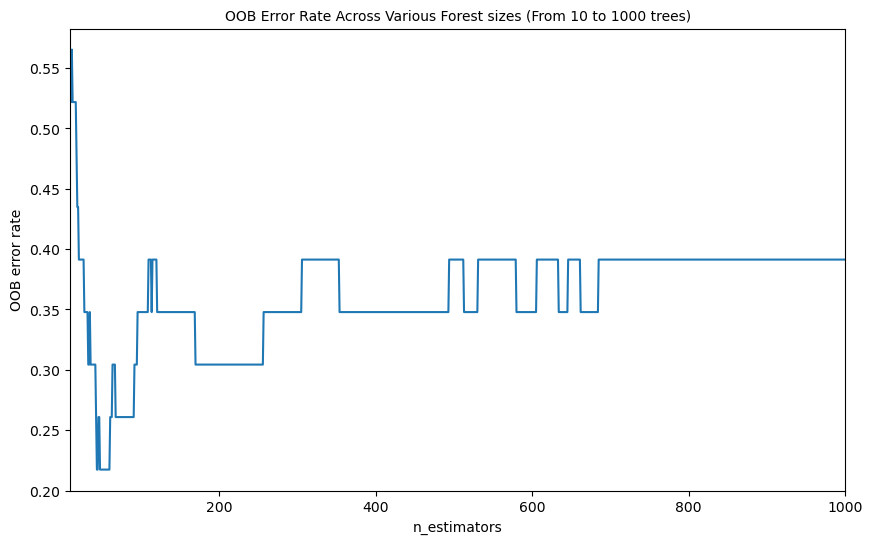

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

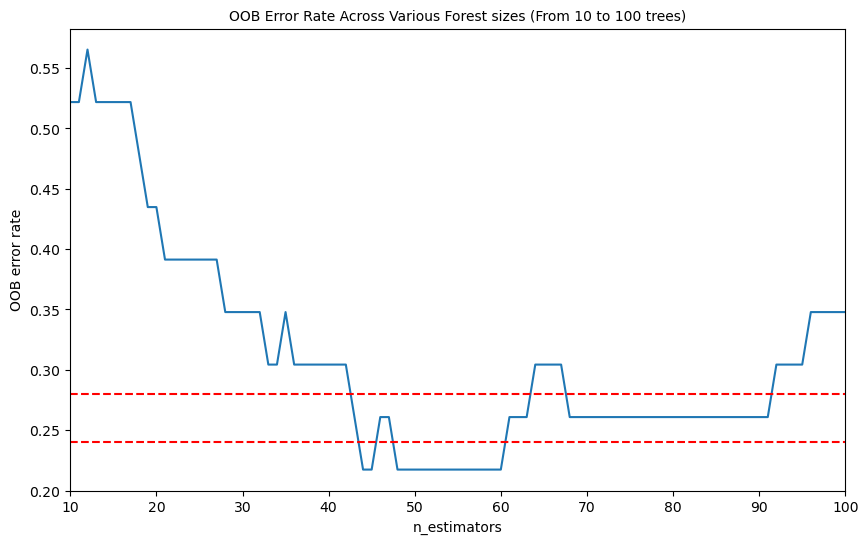

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, 100)
plt.plot(num_estimators, oob_error)
plt.axhline(0.28, color="red", linestyle="--")
plt.axhline(0.24, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

`n_estimators` = 55

### Build Random Forest Model Using Best Parameters

In [78]:
# Create the classifier
fit_rf_img.set_params(bootstrap = True,
                        n_estimators = 55, 
                        max_depth = 80,
                        max_features = "sqrt",
                        criterion= "gini",
                        oob_score = True,
                        random_state = 2)

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=55,
                               oob_score=True, random_state=2)

In [79]:
# Fit the model to the training set
fit_rf_img.fit(X_train_img_prinComps, y_train_img.values.ravel())

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=55,
                               oob_score=True, random_state=2)

### Evaluate Model

#### Train

In [80]:
# Train 
y_train_img_pred = pd.DataFrame(np.argmax(fit_rf_img.oob_decision_function_,axis=1))
y_train_img_pred.columns = ["SURGICAL"]
y_train_img_pred["SURGICAL"] = y_train_img_pred["SURGICAL"].map({1: "M-S", 0: "B-S"})
cmat = mx.confusion_matrix(y_train_img, y_train_img_pred)

In [81]:
printPerformance(cmat)

Accuracy = 0.6522
Precision = 1.0000
Recall = 0.6000
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.7500
Confusion matrix (%):
[[13.04  0.  ]
 [34.78 52.17]]


In [82]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_img.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.348


In [83]:
# Print classification report for model
print(classification_report(y_train_img, y_train_img_pred))

              precision    recall  f1-score   support

         B-S       0.27      1.00      0.43         3
         M-S       1.00      0.60      0.75        20

    accuracy                           0.65        23
   macro avg       0.64      0.80      0.59        23
weighted avg       0.91      0.65      0.71        23



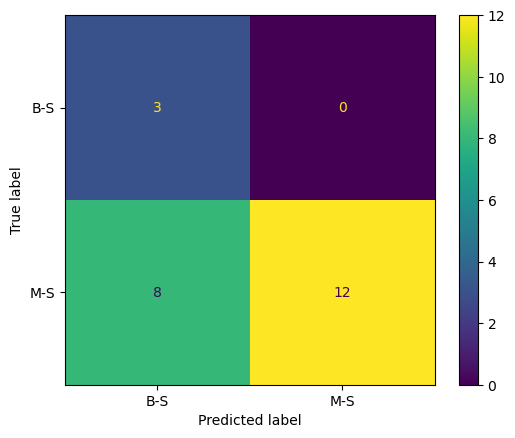

In [84]:
cm = confusion_matrix(y_train_img, y_train_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

#### Test

In [85]:
# Test

# Seperating out the features
X_test_img = image_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
X_test_img = X_test_img.loc[:, X_test_img.columns.isin(spearman_image)]
# Seperating out the target
y_test_img = image_test_df[["SURGICAL"]]

In [86]:
# Create PCA with 2 components
X_test_img_prinComps = image_pca.transform(X_test_img)

print(X_test_img_prinComps.shape)

(6, 2)


In [87]:
y_test_img_pred = fit_rf_img.predict(X_test_img_prinComps)
cmat = mx.confusion_matrix(y_test_img, y_test_img_pred)

In [88]:
printPerformance(cmat)

Accuracy = 0.6667
Precision = 0.6667
Recall = 0.6667
Specificity = 0.6667
False positive rate = 0.3333
F1-score = 0.6667
Confusion matrix (%):
[[33.33 16.67]
 [16.67 33.33]]


In [89]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_img.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.348


In [90]:
# Print classification report for model
print(classification_report(y_test_img, y_test_img_pred))

              precision    recall  f1-score   support

         B-S       0.67      0.67      0.67         3
         M-S       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



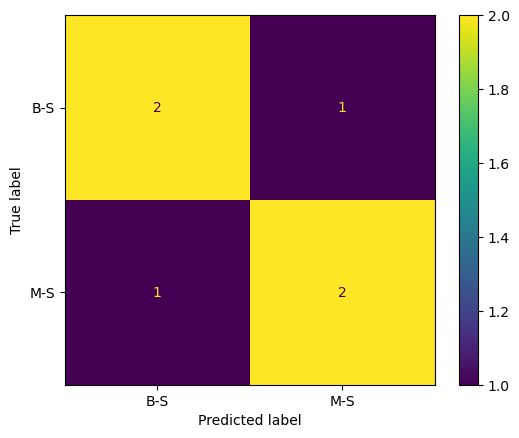

In [91]:
cm = confusion_matrix(y_test_img, y_test_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [92]:
# Validation

# Seperating out the features
X_val_img = image_val_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
X_val_img = X_val_img.loc[:, X_val_img.columns.isin(spearman_image)]
# Seperating out the target
y_val_img = image_val_df[["SURGICAL"]]

In [93]:
# Create PCA with 2 components
X_val_img_prinComps = image_pca.transform(X_val_img)

print(X_val_img_prinComps.shape)

(402, 2)


In [94]:
y_val_img_pred = fit_rf_img.predict(X_val_img_prinComps)
cmat = mx.confusion_matrix(y_val_img, y_val_img_pred)

In [95]:
printPerformance(cmat)

Accuracy = 0.4577
Precision = 0.1931
Recall = 0.6000
Specificity = 0.4251
False positive rate = 0.5749
F1-score = 0.2922
Confusion matrix (%):
[[34.58 46.77]
 [ 7.46 11.19]]


In [96]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_img.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.348


In [97]:
# Print classification report for model
print(classification_report(y_val_img, y_val_img_pred))

              precision    recall  f1-score   support

         B-S       0.82      0.43      0.56       327
         M-S       0.19      0.60      0.29        75

    accuracy                           0.46       402
   macro avg       0.51      0.51      0.43       402
weighted avg       0.71      0.46      0.51       402



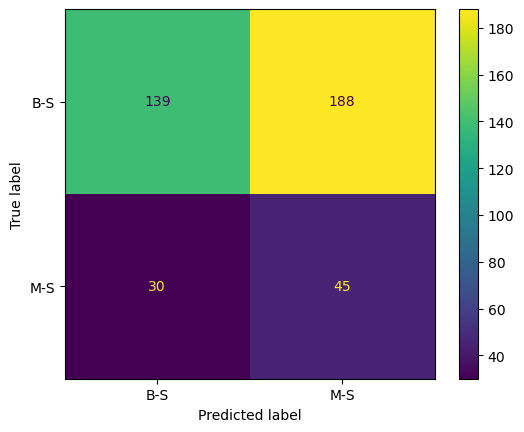

In [98]:
cm = confusion_matrix(y_val_img, y_val_img_pred, labels=fit_rf_img.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_img.classes_)
disp.plot()

### Plot the ROC Curve

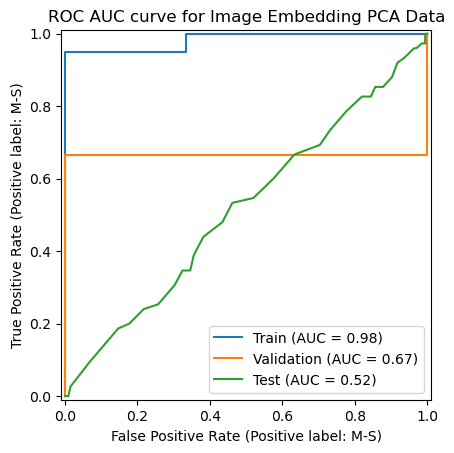

In [99]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_img, X_train_img_prinComps, y_train_img, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_img, X_test_img_prinComps, y_test_img, pos_label='M-S', ax = disp.ax_, name="Validation")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_img, X_val_img_prinComps, y_val_img, pos_label='M-S', ax = disp.ax_, name="Test")

disp.ax_.set_title("ROC AUC curve for Image Embedding PCA Data");

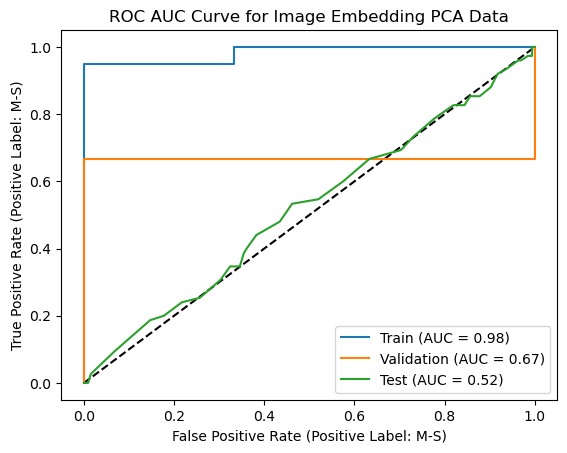

In [100]:
# Train
y_pred_prob1 = fit_rf_img.predict_proba(X_train_img_prinComps)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_train_img, y_pred_prob1, pos_label="M-S")
auc1 = roc_auc_score(y_train_img, y_pred_prob1)

# Test
y_pred_prob2 = fit_rf_img.predict_proba(X_test_img_prinComps)[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_test_img, y_pred_prob2, pos_label="M-S")
auc2 = roc_auc_score(y_test_img, y_pred_prob2)

# Validate
y_pred_prob3 = fit_rf_img.predict_proba(X_val_img_prinComps)[:, 1]
fpr3, tpr3, thresholds3 = roc_curve(y_val_img, y_pred_prob3, pos_label="M-S")
auc3 = roc_auc_score(y_val_img, y_pred_prob3)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr1, tpr1, label="Train (AUC = %0.2f)" % auc1)
plt.plot(fpr2, tpr2, label="Validation (AUC = %0.2f)" % auc2)
plt.plot(fpr3, tpr3, label="Test (AUC = %0.2f)" % auc3)

plt.legend()
plt.xlabel("False Positive Rate (Positive Label: M-S)")
plt.ylabel("True Positive Rate (Positive Label: M-S)")
plt.title('ROC AUC Curve for Image Embedding PCA Data')
plt.show()

## RNA-seq Embeddings

### Create Embedding Master DataFrame

In [101]:
rna_samples_train = []

for rna_idx in range(len(rna_train)):
    rna_tensor =  torch.tensor(rna_train.iloc[rna_idx].values.astype(float)).float()
    rna_samples_train.append(rna_tensor)
    
rna_embeddings_train = [] 

for rna in rna_samples_train:
    rna_tensor = rna.unsqueeze(0).to(device)
    
    with torch.no_grad():
        rna_features = model.rna_encoder(rna_tensor)
        rna_embeddings_train.append(rna_features)
    
rna_embeddings_train = torch.cat(rna_embeddings_train)

In [102]:
rna_embeddings_train.size()

torch.Size([23, 128])

In [103]:
# Scaler for embeddings 
scaler_rna = StandardScaler()

# RNA DataFrame
rna_train_df = pd.DataFrame(scaler_rna.fit_transform(rna_embeddings_train.cpu().numpy()))
rna_train_df.insert(0, "SURGICAL", surg_train)
rna_train_df.insert(0, "image_name", img_train)

In [104]:
rna_train_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,0.304861,0.436218,0.064396,0.129112,0.154661,-0.544508,0.162488,0.965045,...,-0.818838,-0.574058,-0.274951,0.504377,0.729716,-0.240964,-0.297036,0.546716,0.341730,-0.169131
1,14984_0039.nii.gz,M-S,-0.951101,-1.074152,-0.956899,-0.767024,-1.444273,0.762624,-1.116339,0.272712,...,0.017743,1.073963,0.978063,-1.474552,-1.061243,1.041335,0.961776,-0.541563,-1.354614,1.031505
2,14056_3.nii.gz,M-S,-1.635989,-1.462788,-1.556259,-1.620565,-0.921801,2.712524,-1.553909,-1.713926,...,0.129878,-1.651163,1.187834,-1.547241,-1.456708,1.672042,1.500290,-1.695276,-1.611549,1.121053
3,25962_0006.nii.gz,M-S,1.401163,1.555053,1.392733,1.195136,1.347291,-1.156185,1.526976,1.352748,...,-0.848828,1.984759,-1.212096,1.148925,1.404802,-1.443003,-1.610782,1.253389,1.335076,-1.320378
4,26604_0007.nii.gz,M-S,0.589761,0.453263,0.813237,0.627795,0.936244,-0.202328,0.668676,0.337964,...,-1.451478,-0.017765,-0.713423,0.557491,0.523457,-0.713380,-0.509064,0.286940,0.715725,-0.353143
5,26428_0020.nii.gz,M-S,-1.221494,-1.144590,-1.050444,-1.377577,-1.909562,1.448675,-1.412095,-1.092005,...,1.444034,-0.865468,1.563099,-1.560754,-1.524432,1.302059,0.835535,-1.216830,-1.132384,1.339122
6,187867.nii.gz,M-S,0.626427,0.596827,0.645183,0.673602,0.797488,-0.779459,0.747957,0.004331,...,-0.231131,0.925805,-0.617890,0.799909,0.558893,-0.680508,-0.642444,0.602965,0.857254,-0.779952
7,14654_3.nii.gz,M-S,-1.145689,-0.546598,-1.419401,-1.149243,-0.828405,0.709405,-1.156941,-1.557694,...,1.419620,-1.531419,0.770647,-0.976314,-1.232602,0.886761,1.344901,-0.878808,-1.149635,1.098795
8,16439_0004.nii.gz,B-S,-0.170944,0.068178,0.217362,-0.332702,0.180586,-0.811594,0.328054,0.485278,...,-0.113412,0.575113,-0.090565,0.278592,0.392860,-0.107018,0.055211,0.176423,0.035744,0.036075
9,14024_2.nii.gz,M-S,-0.672325,-0.617358,-0.941397,-0.946124,-0.527032,0.341233,-0.822879,0.109970,...,0.678812,-1.642437,0.834030,-0.505580,-0.943887,1.135899,0.620300,-0.545011,-1.036950,1.111368


In [105]:
rna_samples_test = []

for rna_idx in range(len(rna_test)):
    rna_tensor =  torch.tensor(rna_test.iloc[rna_idx].values.astype(float)).float()
    rna_samples_test.append(rna_tensor)
    
rna_embeddings_test = [] 

for rna in rna_samples_test:
    rna_tensor = rna.unsqueeze(0).to(device)
    
    with torch.no_grad():
        rna_features = model.rna_encoder(rna_tensor)
        rna_embeddings_test.append(rna_features)
    
rna_embeddings_test = torch.cat(rna_embeddings_test)

In [106]:
rna_embeddings_test.size()

torch.Size([6, 128])

In [107]:
# RNA DataFrame
rna_test_df = pd.DataFrame(scaler_rna.transform(rna_embeddings_test.cpu().numpy()))
rna_test_df.insert(0, "SURGICAL", surg_test)
rna_test_df.insert(0, "image_name", img_test)

In [108]:
rna_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,13291_0010.nii.gz,M-S,0.670798,0.700082,0.868689,1.058150,1.562031,-1.039619,0.560173,0.402995,...,-0.303893,0.740239,-0.678870,0.178701,0.946760,-0.814368,-0.951108,0.854305,0.596030,-0.035493
1,12930_3.nii.gz,B-S,0.487678,0.401006,0.779773,0.376961,1.030312,-1.716983,0.809758,-0.958574,...,0.139269,2.459620,-0.979212,1.029577,0.042923,-0.699766,-0.615546,0.816692,0.606308,-1.082862
2,18852_0009.nii.gz,B-S,-1.184990,-0.576956,-0.837747,-1.826173,-0.009859,-0.053762,-0.425208,-1.228296,...,1.667748,0.753207,0.497600,-0.578664,-0.350797,0.867316,0.849888,-0.805995,-0.753633,0.039465
3,16208_1.nii.gz,B-S,0.973416,1.155890,1.120134,1.239754,1.734457,-1.363590,1.235755,0.608062,...,-0.563429,0.779529,-0.858057,1.184229,1.083219,-1.040902,-1.168541,1.195372,1.142216,-1.297356
4,25961_2.nii.gz,M-S,-2.862439,-2.879571,-2.626805,-4.073874,-0.987240,2.665032,-3.512827,-0.210397,...,0.986708,-3.205850,2.167520,-3.699502,-3.412678,3.584387,3.550390,-4.065466,-3.139885,2.727920
5,26424_0007.nii.gz,M-S,-1.425826,-1.126770,-1.253811,-1.647400,-1.790277,1.403639,-1.688969,-0.517878,...,-0.057387,-1.266953,1.894252,-1.276294,-1.828264,1.524121,1.806509,-1.952209,-1.558465,1.246453


In [109]:
rna_samples_val = []

for rna_idx in range(len(rna_val)):
    rna_tensor =  torch.tensor(rna_val.iloc[rna_idx].values.astype(float)).float()
    rna_samples_val.append(rna_tensor)
    
rna_embeddings_val = [] 

for rna in rna_samples_val:
    rna_tensor = rna.unsqueeze(0).to(device)
    
    with torch.no_grad():
        rna_features = model.rna_encoder(rna_tensor)
        rna_embeddings_val.append(rna_features)
    
rna_embeddings_val = torch.cat(rna_embeddings_val)

In [110]:
rna_embeddings_val.size()

torch.Size([38, 128])

In [111]:
# RNA DataFrame
surg_val = match_rna_df["SURGICAL"].tolist()
rna_val_df = pd.DataFrame(scaler_rna.transform(rna_embeddings_val.cpu().numpy()))
rna_val_df.insert(0, "SURGICAL", surg_val)

In [112]:
rna_val_df

,SURGICAL,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,B-S,0.487678,0.401006,0.779773,0.376961,1.030312,-1.716983,0.809758,-0.958574,-0.650600,...,0.139269,2.459620,-0.979212,1.029577,0.042923,-0.699766,-0.615546,0.816692,0.606308,-1.082862
1,M-S,0.670798,0.700082,0.868689,1.058150,1.562031,-1.039619,0.560173,0.402995,-0.620328,...,-0.303893,0.740239,-0.678870,0.178701,0.946760,-0.814368,-0.951108,0.854305,0.596030,-0.035493
2,M-S,1.607879,1.557609,1.564491,1.689737,1.435792,-1.297981,1.785042,1.807203,-1.665949,...,-1.155035,1.214257,-1.772535,1.587588,1.196062,-1.793491,-1.492807,1.774761,1.887910,-1.482921
3,M-S,0.428881,0.278689,0.332340,0.509593,0.264370,-0.433150,0.254448,1.175064,-0.469715,...,0.578548,0.449718,-0.414961,0.496519,0.078545,-0.017132,-0.400539,0.318888,0.412241,-0.324445
4,M-S,-1.635989,-1.462788,-1.556259,-1.620565,-0.921801,2.712524,-1.553909,-1.713926,1.649607,...,0.129878,-1.651163,1.187834,-1.547241,-1.456708,1.672042,1.500290,-1.695276,-1.611549,1.121053
5,M-S,-1.145689,-0.546598,-1.419401,-1.149243,-0.828405,0.709405,-1.156941,-1.557694,1.234131,...,1.419620,-1.531419,0.770647,-0.976314,-1.232602,0.886761,1.344901,-0.878808,-1.149635,1.098795
6,M-S,-0.672325,-0.617358,-0.941397,-0.946124,-0.527032,0.341233,-0.822879,0.109970,0.876240,...,0.678812,-1.642437,0.834030,-0.505580,-0.943887,1.135899,0.620300,-0.545011,-1.036950,1.111368
7,M-S,-0.951101,-1.074152,-0.956899,-0.767024,-1.444273,0.762624,-1.116339,0.272712,1.258647,...,0.017743,1.073963,0.978063,-1.474552,-1.061243,1.041335,0.961776,-0.541563,-1.354614,1.031505
8,B-S,0.069526,0.112786,-0.174055,0.167985,0.169964,-0.044089,0.038920,0.408383,-0.026181,...,0.209232,0.548087,0.300537,0.244312,0.079872,-0.037531,0.067493,0.213721,0.246199,-0.297468
9,M-S,0.284865,0.144927,-0.191420,0.248261,0.027696,0.635461,-0.055542,-0.128793,-0.127925,...,0.661655,0.136281,-0.365967,0.389335,0.442471,-0.069937,0.099964,0.273063,0.013618,-0.774342


In [113]:
# Filter features selected using Spearman Rho
rna_features = rna_train_df.drop(["image_name", "SURGICAL"], axis=1)
rna_class_cat = pd.Categorical(rna_train_df["SURGICAL"].astype("category")).codes

In [114]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_features, rna_class_cat, thresholds)

In [115]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,60
1,0.1,33
2,0.2,9
3,0.3,2
4,0.4,0
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


In [116]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_features, rna_class_cat, 0.2)

In [117]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,5,0.311400
1,20,0.350325
2,33,0.214087
3,56,0.233550
4,72,0.253012
5,76,0.214087
6,108,0.233550
7,113,0.214087
8,116,0.214087


In [118]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [119]:
# Seperating out the features
X_train_rna = rna_train_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
X_train_rna = rna_features.loc[:, rna_features.columns.isin(spearman_rna)]
# Seperating out the target
y_train_rna = rna_train_df[["SURGICAL"]]

In [120]:
# Create PCA with 2 components
rna_pca = PCA(n_components=2)
X_train_rna_prinComps = rna_pca.fit_transform(X_train_rna)

print(X_train_rna_prinComps.shape)

(23, 2)


### Fit Random Forest Model

In [121]:
# Set the random state for reproducibility
fit_rf_rna = BalancedRandomForestClassifier(n_estimators=1000, 
                                    random_state=2)

In [122]:
# Hyperparameter optimisation
param_dist = {"bootstrap": [True, False],
    "max_depth": [80, 90, 100, 110],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "criterion": ["gini", "entropy"]}

cv_rf_rna = GridSearchCV(fit_rf_rna, cv=3, param_grid=param_dist, verbose=3)

In [123]:
cv_rf_rna.fit(X_train_rna_prinComps, y_train_rna.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rna.best_params_)

Fitting 3 folds for each of 80 candidates, totalling 240 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.125 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.500 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=sqrt;, score=0.429 total time=   1.6s
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.125 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.500 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=log2;, score=0.429 total time=   1.6s
[CV 1/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=0.5;, score=0.125 total time=   1.6s
[CV 2/3] END bootstrap=True, criterion=gini, max_depth=80, max_features=0.5;, score=0.500 total time=   1.6s
[CV 3/3] END bootstrap=True, criterion=gini, max_depth=80, m

`Best Parameters using grid search: 
 {'bootstrap': False, 'criterion': 'gini', 'max_depth': 80, 'max_features': None}`

In [124]:
# Set best parameters given by grid search
fit_rf_rna.set_params(bootstrap = True,
                        criterion = "gini",
                        max_depth = 80,
                        max_features = None)

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, max_features=None,
                               n_estimators=1000, random_state=2)

### Out of Bag Error Rate

In [125]:
fit_rf_rna.set_params(n_estimators=100,
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rna.set_params(n_estimators=i)
    fit_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())

    oob_error = 1 - fit_rf_rna.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:825: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/pyth

min_oob_error =  0.3913043478260869
min_index =  636


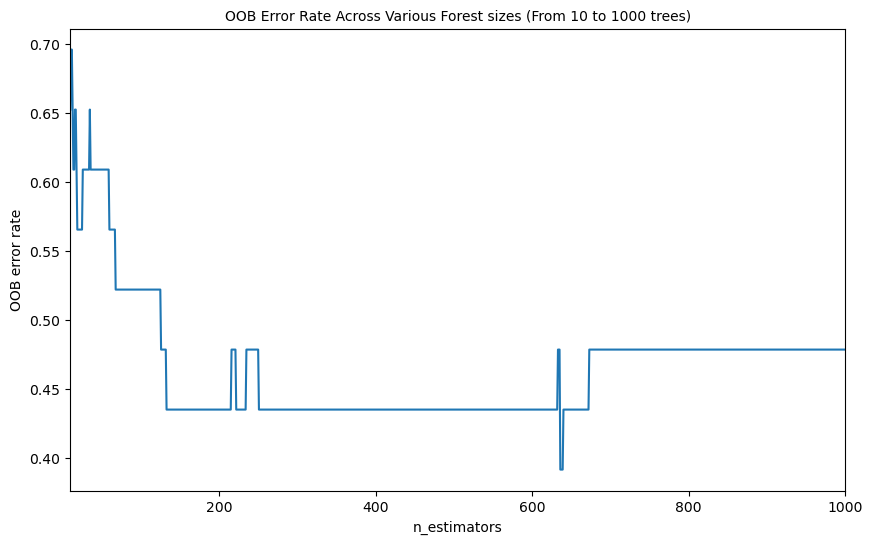

In [126]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

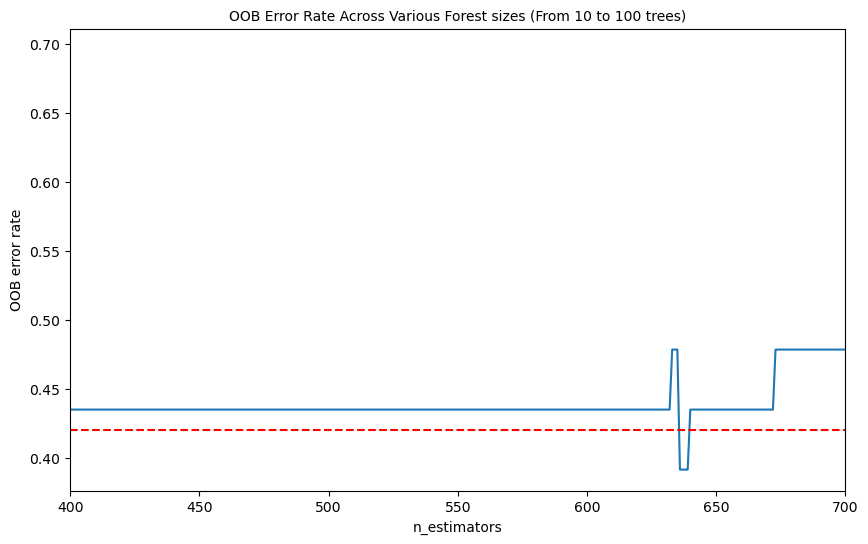

In [130]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(400, 700)
plt.plot(num_estimators, oob_error)
plt.axhline(0.42, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

`n_estimators` = 640

### Build Random Forest Model Using Best Parameters

In [131]:
# Create the classifier
fit_rf_rna.set_params(bootstrap = True,
                        n_estimators = 640, 
                        max_depth = 80,
                        max_features = None,
                        criterion= "gini",
                        oob_score = True,
                        random_state = 2)

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, max_features=None,
                               n_estimators=640, oob_score=True,
                               random_state=2)

In [132]:
# Fit the model to the training set
fit_rf_rna.fit(X_train_rna_prinComps, y_train_rna.values.ravel())

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, max_features=None,
                               n_estimators=640, oob_score=True,
                               random_state=2)

### Evaluate Model

#### Train

In [133]:
# Train 
y_train_rna_pred = pd.DataFrame(np.argmax(fit_rf_rna.oob_decision_function_,axis=1))
y_train_rna_pred.columns = ["SURGICAL"]
y_train_rna_pred["SURGICAL"] = y_train_rna_pred["SURGICAL"].map({1: "M-S", 0: "B-S"})
cmat = mx.confusion_matrix(y_train_rna, y_train_rna_pred)

In [134]:
printPerformance(cmat)

Accuracy = 0.3913
Precision = 1.0000
Recall = 0.3000
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.4615
Confusion matrix (%):
[[13.04  0.  ]
 [60.87 26.09]]


In [135]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rna.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.609


In [136]:
# Print classification report for model
print(classification_report(y_train_rna, y_train_rna_pred))

              precision    recall  f1-score   support

         B-S       0.18      1.00      0.30         3
         M-S       1.00      0.30      0.46        20

    accuracy                           0.39        23
   macro avg       0.59      0.65      0.38        23
weighted avg       0.89      0.39      0.44        23



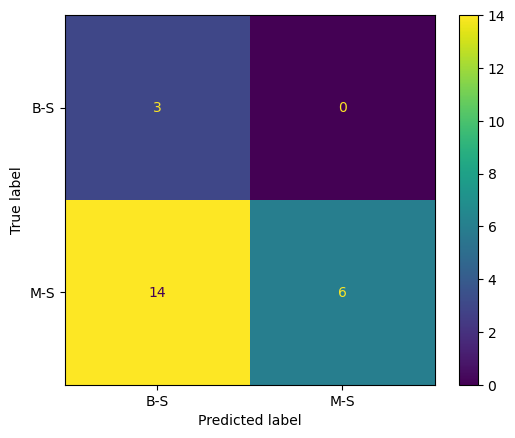

In [137]:
cm = confusion_matrix(y_train_rna, y_train_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Test

In [138]:
# Test

# Seperating out the features
X_test_rna = rna_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
X_test_rna = X_test_rna.loc[:, X_test_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_test_rna = rna_test_df[["SURGICAL"]]

In [139]:
# Create PCA with 2 components
X_test_rna_prinComps = rna_pca.transform(X_test_rna)

print(X_test_rna_prinComps.shape)

(6, 2)


In [140]:
y_test_rna_pred = fit_rf_rna.predict(X_test_rna_prinComps)
cmat = mx.confusion_matrix(y_test_rna, y_test_rna_pred)

In [141]:
printPerformance(cmat)

Accuracy = 0.3333
Precision = 0.4000
Recall = 0.6667
Specificity = 0.0000
False positive rate = 1.0000
F1-score = 0.5000
Confusion matrix (%):
[[ 0.   50.  ]
 [16.67 33.33]]


In [142]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rna.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.609


In [143]:
# Print classification report for model
print(classification_report(y_test_rna, y_test_rna_pred))

              precision    recall  f1-score   support

         B-S       0.00      0.00      0.00         3
         M-S       0.40      0.67      0.50         3

    accuracy                           0.33         6
   macro avg       0.20      0.33      0.25         6
weighted avg       0.20      0.33      0.25         6



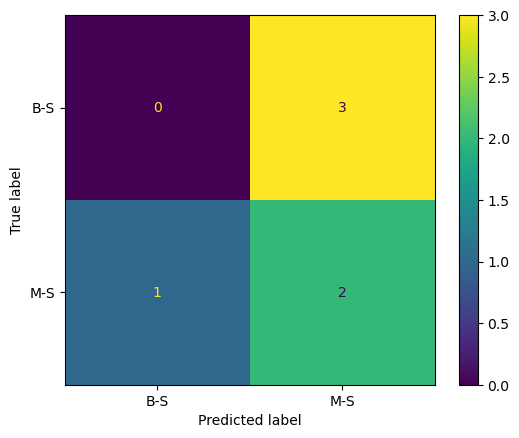

In [144]:
cm = confusion_matrix(y_test_rna, y_test_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [145]:
# Validation

# Seperating out the features
X_val_rna = rna_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rna = X_val_rna.loc[:, X_val_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_val_rna = rna_val_df[["SURGICAL"]]

In [146]:
# Create PCA with 2 components
X_val_rna_prinComps = rna_pca.transform(X_val_rna)

print(X_val_rna_prinComps.shape)

(38, 2)


In [147]:
y_val_rna_pred = fit_rf_rna.predict(X_val_rna_prinComps)
cmat = mx.confusion_matrix(y_val_rna, y_val_rna_pred)

In [148]:
printPerformance(cmat)

Accuracy = 0.6053
Precision = 0.8696
Recall = 0.6250
Specificity = 0.5000
False positive rate = 0.5000
F1-score = 0.7273
Confusion matrix (%):
[[ 7.89  7.89]
 [31.58 52.63]]


In [149]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rna.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.609


In [150]:
# Print classification report for model
print(classification_report(y_val_rna, y_val_rna_pred))

              precision    recall  f1-score   support

         B-S       0.20      0.50      0.29         6
         M-S       0.87      0.62      0.73        32

    accuracy                           0.61        38
   macro avg       0.53      0.56      0.51        38
weighted avg       0.76      0.61      0.66        38



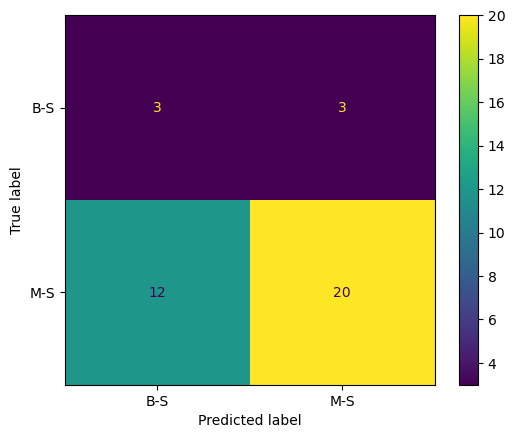

In [151]:
cm = confusion_matrix(y_val_rna, y_val_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

### Plot the ROC Curve

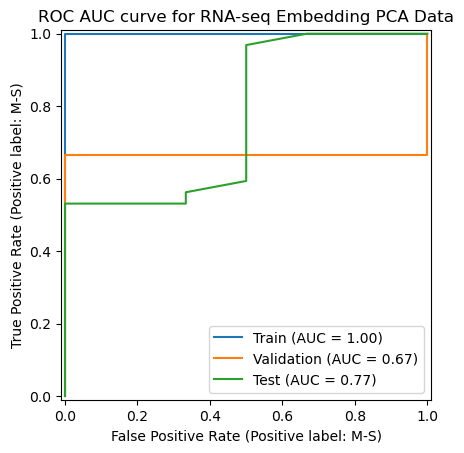

In [152]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_train_rna_prinComps, y_train_rna, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_test_rna_prinComps, y_test_rna, pos_label='M-S', ax = disp.ax_, name="Validation")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_val_rna_prinComps, y_val_rna, pos_label='M-S', ax = disp.ax_, name="Test")

disp.ax_.set_title("ROC AUC curve for RNA-seq Embedding PCA Data");

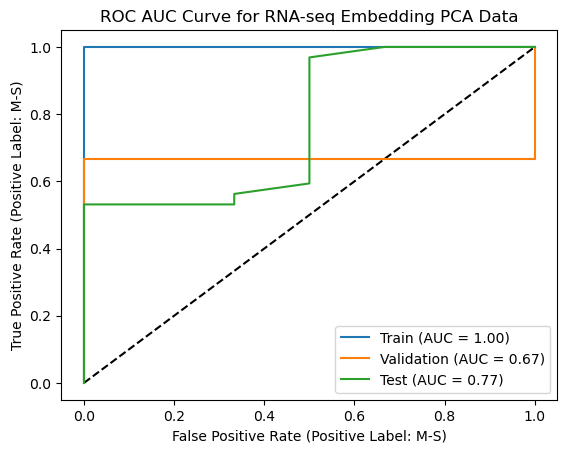

In [153]:
# Train
y_pred_prob1 = fit_rf_rna.predict_proba(X_train_rna_prinComps)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_train_rna, y_pred_prob1, pos_label="M-S")
auc1 = roc_auc_score(y_train_rna, y_pred_prob1)

# Test
y_pred_prob2 = fit_rf_rna.predict_proba(X_test_rna_prinComps)[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_test_rna, y_pred_prob2, pos_label="M-S")
auc2 = roc_auc_score(y_test_rna, y_pred_prob2)

# Validate
y_pred_prob3 = fit_rf_rna.predict_proba(X_val_rna_prinComps)[:, 1]
fpr3, tpr3, thresholds3 = roc_curve(y_val_rna, y_pred_prob3, pos_label="M-S")
auc3 = roc_auc_score(y_val_rna, y_pred_prob3)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr1, tpr1, label="Train (AUC = %0.2f)" % auc1)
plt.plot(fpr2, tpr2, label="Validation (AUC = %0.2f)" % auc2)
plt.plot(fpr3, tpr3, label="Test (AUC = %0.2f)" % auc3)

plt.legend()
plt.xlabel("False Positive Rate (Positive Label: M-S)")
plt.ylabel("True Positive Rate (Positive Label: M-S)")
plt.title('ROC AUC Curve for RNA-seq Embedding PCA Data')
plt.show()